# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [1]:
from imports import *
from vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

## Try with Bayes Agent (Vectorized)

In [2]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True)

In [3]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 10000/10000 [00:01<00:00, 8319.61it/s]


steps:  10000
conclusion:  0.91
conclusion core 0.91


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.399908,0.785594,0.682429,0.517364,0.749535,0.289591,0.972519,0.580385,0.991284,0.262658,...,0.860208,0.513240,0.560552,0.003946,0.351559,0.409079,0.545312,0.024311,0.419447,0.414599
1,0.405681,0.801320,0.684160,0.521358,0.748030,0.291240,0.972944,0.590094,0.991284,0.261111,...,0.855328,0.515238,0.570380,0.003915,0.355215,0.422682,0.545312,0.026695,0.407806,0.399156
2,0.397989,0.801320,0.687607,0.507370,0.749535,0.286311,0.971430,0.593959,0.991949,0.265768,...,0.853337,0.501243,0.562521,0.003615,0.344299,0.436403,0.549276,0.026695,0.400101,0.402999


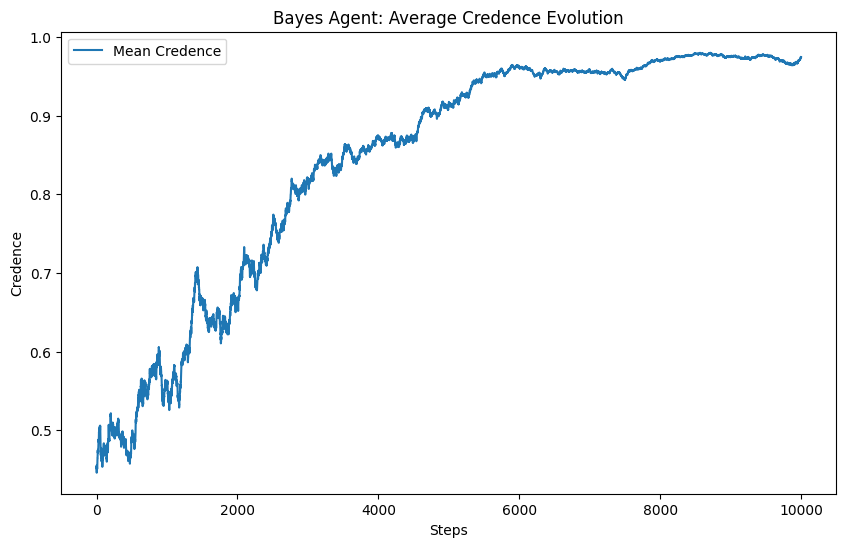

In [4]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [5]:
n_agents = 100
my_network = nx.gnp_random_graph(n_agents, p=0.2, directed=True)

In [6]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:02<00:00, 4536.80it/s]


steps:  10000
conclusion:  0.81


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,"[0.06793160340083991, 0.08920811120425282]","[0.5665053574304612, 0.3842276401188069]","[0.9074107136252796, 0.14671187220701068]","[0.2664507687425209, 0.972120517301865]","[0.7654604008482927, 0.6201887966111193]","[0.18499432331006505, 0.3699498912360913]","[0.3883655446938616, 0.332042126365632]","[0.767079456613223, 0.9913673586701245]","[0.6533099910561647, 0.9470866416654964]","[3.2484243027501357e-50, 0.9497485025099487]",...,"[0.42734653843475545, 0.9981442535688115]","[0.6690671598294491, 0.414274951254025]","[0.48880991839429605, 0.3562858054442138]","[0.348510428729323, 1.0]","[0.7597720801694443, 0.03197401446554679]","[5.0727300169536624e-05, 0.6282847075996612]","[0.18389658501527018, 0.6644395327567053]","[0.3982958720162267, 0.4196733055355668]","[0.10546830743462761, 0.022280051798274803]","[0.9637049202955117, 0.8750749107160752]"
1,"[0.4007094233932021, 0.38200089759364586]","[0.4528813171804005, 0.5544582357734115]","[0.36188392698547506, 0.4985307111667686]","[0.4626554214315741, 0.5107175428188157]","[0.43530297952136426, 0.5116792974459631]","[0.38808280267918166, 0.5710771438108306]","[0.43124352881717753, 0.4732835164781256]","[0.5408796172218626, 0.3826246978559278]","[0.41208634735703015, 0.5159108341280448]","[0.47462661300746967, 0.4169109249055083]",...,"[0.40979190745716443, 0.5250431501012259]","[0.4320031008613673, 0.4337840171178516]","[0.4489263695926232, 0.6007052936006528]","[0.3995777973214297, 0.6909754193981409]","[0.5745517442811504, 0.49011844280376493]","[0.5599800992128342, 0.6209195826026244]","[0.436826766412556, 0.5734253392466917]","[0.5441244568005074, 0.39839769727102237]","[0.3312854191150198, 0.4641598406957974]","[0.5287929702807043, 0.438963384041763]"
2,"[0.5589032607276186, 0.5170131443690686]","[0.4163593558381517, 0.5465367702392088]","[0.3896859182932725, 0.4317287739176229]","[0.5563299903160674, 0.6630914276235719]","[0.4847874722062425, 0.508569121085045]","[0.4244939727017566, 0.5747560685924875]","[0.4603454715043072, 0.4778458440338603]","[0.48642314610757365, 0.5003922724022479]","[0.4617905973484733, 0.4908313987341868]","[0.5764104661063315, 0.44266181724337733]",...,"[0.5039008718831928, 0.5322096211297778]","[0.5559648450512978, 0.4388083522682461]","[0.4576489997115717, 0.5530245516634462]","[0.5229818325877735, 0.6398268355453952]","[0.49537427186666727, 0.4864673019413021]","[0.4428998589726798, 0.5317585281530363]","[0.5312153474392534, 0.636520668339745]","[0.45194157304123445, 0.51190333230987]","[0.3436146343686316, 0.48862404075019283]","[0.4294669174083699, 0.5593925361640757]"


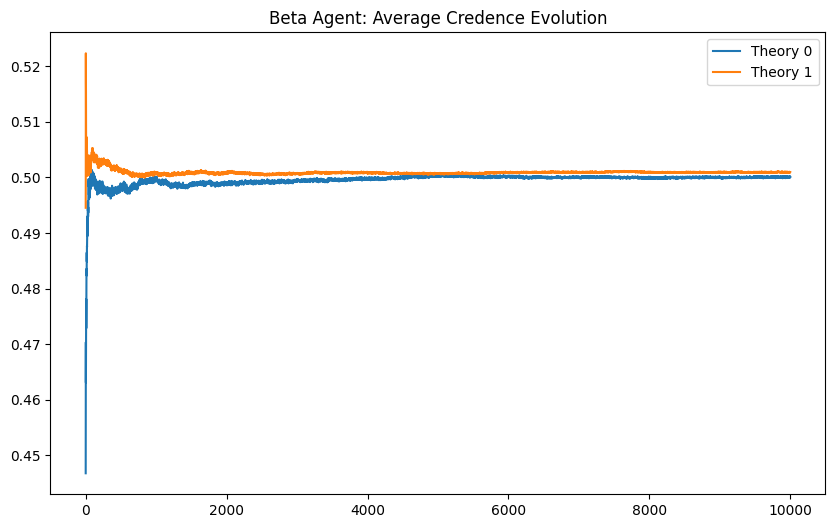

In [7]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

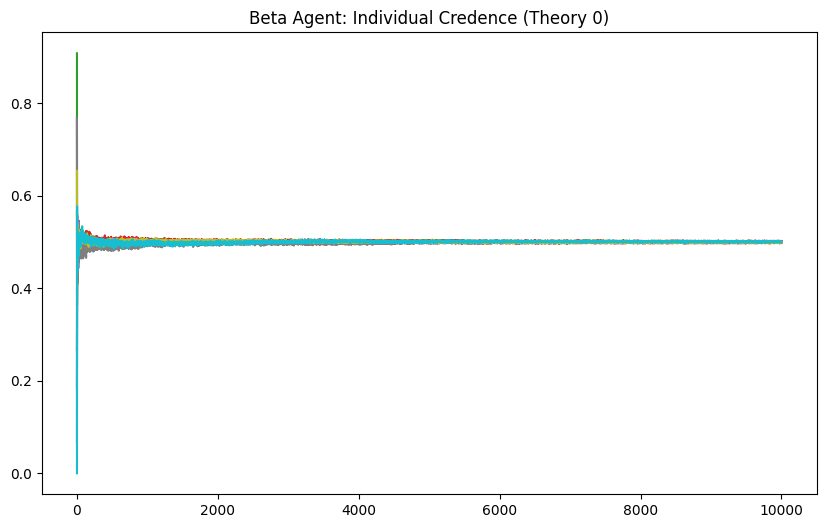

In [8]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()